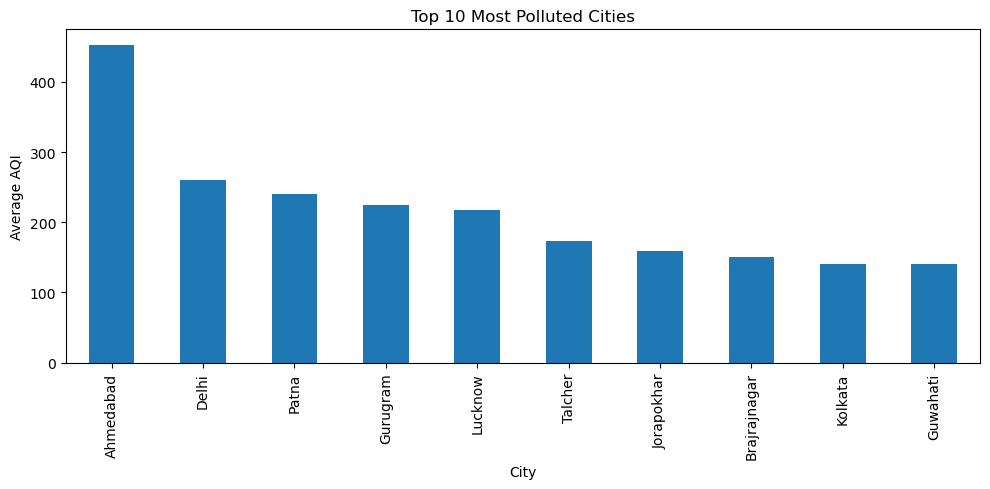

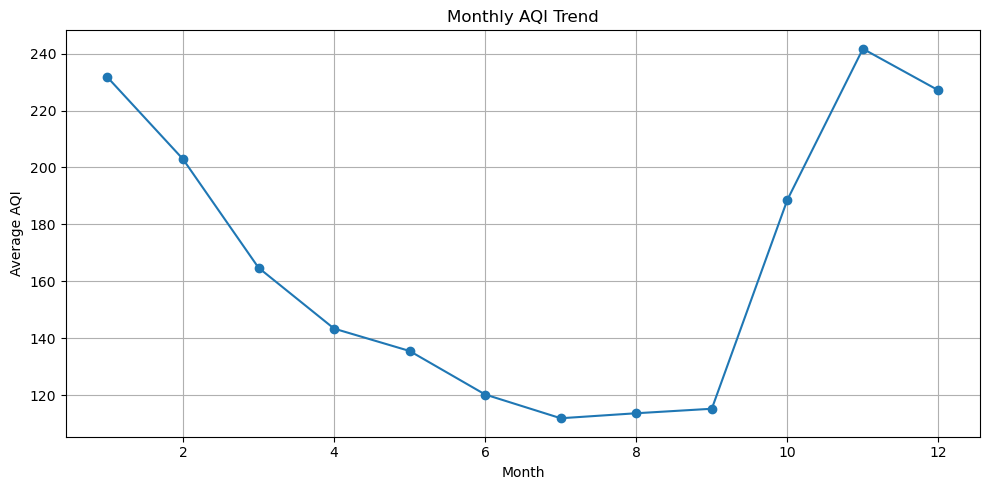

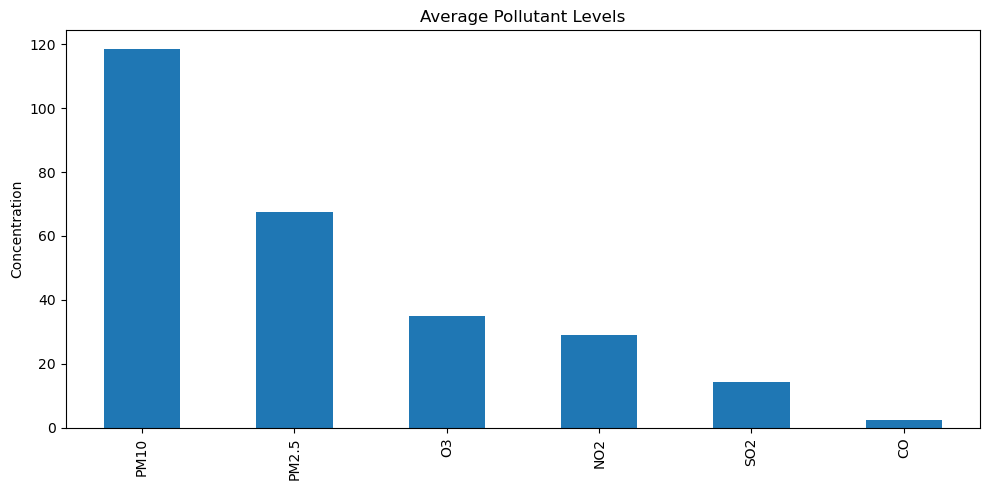


========== INSIGHTS ==========

Top 5 Most Polluted Cities:
City
Ahmedabad    452.122939
Delhi        259.487744
Patna        240.782042
Gurugram     225.123882
Lucknow      217.973059
Name: AQI, dtype: float64

Highest Pollutant:
PM10

Average AQI: 166.46
Maximum AQI: 2049.0
Minimum AQI: 13.0
Total Cities: 26
Total Records: 24850


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("city_day.csv")

df["Date"] = pd.to_datetime(df["Date"])
df["AQI"] = pd.to_numeric(df["AQI"], errors="coerce")

df = df.dropna(subset=["AQI"])
df = df.drop_duplicates()

top_polluted = df.groupby("City")["AQI"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_polluted.plot(kind="bar")
plt.title("Top 10 Most Polluted Cities")
plt.ylabel("Average AQI")
plt.tight_layout()
plt.show()

df["Month"] = df["Date"].dt.month

monthly_aqi = df.groupby("Month")["AQI"].mean()

plt.figure(figsize=(10,5))
monthly_aqi.plot(marker="o")
plt.title("Monthly AQI Trend")
plt.ylabel("Average AQI")
plt.grid(True)
plt.tight_layout()
plt.show()

pollutants = ["PM2.5","PM10","NO2","SO2","CO","O3"]
available = [col for col in pollutants if col in df.columns]

avg_pollutants = df[available].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
avg_pollutants.plot(kind="bar")
plt.title("Average Pollutant Levels")
plt.ylabel("Concentration")
plt.tight_layout()
plt.show()

print("\n========== INSIGHTS ==========")
print("\nTop 5 Most Polluted Cities:")
print(top_polluted.head())

print("\nHighest Pollutant:")
print(avg_pollutants.idxmax())

print("\nAverage AQI:", round(df["AQI"].mean(), 2))
print("Maximum AQI:", round(df["AQI"].max(), 2))
print("Minimum AQI:", round(df["AQI"].min(), 2))
print("Total Cities:", df["City"].nunique())
print("Total Records:", len(df))